<a href="https://colab.research.google.com/github/2303A52060/High-performace-computing/blob/main/hpc_ass_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1: Serial Recursive Fibonacci (Baseline)

Aim

Measure the execution time of a serial recursive
Fibonacci algorithm and understand the computational
cost of recursion and overlapping subproblems.

Requirements

 C compiler (gcc)

 Standard C libraries

 Linux / HPC lab system


In [3]:
import time

def fibonacci_python(n):
    if n <= 1:
        return n
    return fibonacci_python(n - 1) + fibonacci_python(n - 2)

def run_python_fibonacci():
    n = int(input("Enter a non-negative integer (e.g., 35 for a noticeable delay in Python): "))

    if n < 0:
        print("Please enter a non-negative integer.")
        return

    start_time = time.time()  # Start timer
    result = fibonacci_python(n)
    end_time = time.time()    # End timer

    execution_time = end_time - start_time

    print(f"Fibonacci({n}) = {result}")
    print(f"Execution time: {execution_time:.6f} seconds")

run_python_fibonacci()

Enter a non-negative integer (e.g., 35 for a noticeable delay in Python): 40
Fibonacci(40) = 102334155
Execution time: 12.798406 seconds


Section 2: OpenMP Task-based Fibonacci (Basic
Tasking)

Aim

Implement OpenMP task-based parallelism for a
recursive Fibonacci algorithm and observe performance
improvement over the serial version.
Requirements

 C compiler with OpenMP support (gcc -
fopenmp)

 OpenMP library


In [5]:
import time
from concurrent.futures import ProcessPoolExecutor

# Serial Fibonacci function for the base cases or smaller problems
def fibonacci_serial(n):
    if n <= 1:
        return n
    return fibonacci_serial(n - 1) + fibonacci_serial(n - 2)

# This helper function performs Fibonacci calculation.
# It will be submitted to the ProcessPoolExecutor.
# It does not take the executor as an argument to avoid pickling errors.
def _fibonacci_task_worker(n, cutoff):
    if n <= cutoff:
        return fibonacci_serial(n)
    # If n is still large within a worker, it proceeds serially for its sub-problems
    # to avoid re-submitting tasks to the main executor or creating new executors.
    return _fibonacci_task_worker(n - 1, cutoff) + _fibonacci_task_worker(n - 2, cutoff)

def run_python_parallel_fibonacci():
    n = int(input("Enter a non-negative integer (e.g., 35-40 for parallel demo): "))
    num_processes = int(input("Enter number of processes (e.g., 4): "))

    if n < 0:
        print("Please enter a non-negative integer.")
        return

    # Define a cutoff for the initial split.
    # Below this cutoff, computation reverts to serial.
    # The worker function itself also uses this cutoff to decide when to stop recursing serially.
    CUTOFF = 25
    print(f"Running parallel Fibonacci with n={n}, {num_processes} processes, and cutoff={CUTOFF}")

    start_time = time.time()  # Start timer

    with ProcessPoolExecutor(max_workers=num_processes) as executor:
        if n <= CUTOFF: # If the initial 'n' is already small, run serially.
            result = fibonacci_serial(n)
        else:
            # Submit the two main recursive calls as separate tasks to the process pool.
            # These tasks will then run _fibonacci_task_worker which handles further recursion serially.
            future1 = executor.submit(_fibonacci_task_worker, n - 1, CUTOFF)
            future2 = executor.submit(_fibonacci_task_worker, n - 2, CUTOFF)

            # Wait for the results of the submitted tasks
            result = future1.result() + future2.result()

    end_time = time.time()    # End timer

    execution_time = end_time - start_time

    print(f"Fibonacci({n}) = {result}")
    print(f"Execution time (Parallel Python): {execution_time:.6f} seconds")

# Execute the parallel Python Fibonacci function
run_python_parallel_fibonacci()

Enter a non-negative integer (e.g., 35-40 for parallel demo): 35
Enter number of processes (e.g., 4): 4
Running parallel Fibonacci with n=35, 4 processes, and cutoff=25
Fibonacci(35) = 9227465
Execution time (Parallel Python): 0.744424 seconds


Section 3: Task Creation and Synchronization using taskwait

Aim

Understand task synchronization in OpenMP by using #pragma omp taskwait to control execution order in
recursive algorithms.

In [6]:
  import time
  from concurrent.futures import ProcessPoolExecutor

  # Serial Fibonacci function for the base cases or smaller problems
  def fibonacci_serial(n):
      if n <= 1:
          return n
      return fibonacci_serial(n - 1) + fibonacci_serial(n - 2)

  # This helper function performs Fibonacci calculation.
  # It will be submitted to the ProcessPoolExecutor.
  # It does not take the executor as an argument to avoid pickling errors.
  def _fibonacci_task_worker(n, cutoff):
      if n <= cutoff:
          return fibonacci_serial(n)
      # If n is still large within a worker, it proceeds serially for its sub-problems
      # to avoid re-submitting tasks to the main executor or creating new executors.
      return _fibonacci_task_worker(n - 1, cutoff) + _fibonacci_task_worker(n - 2, cutoff)

  def run_python_parallel_fibonacci_with_sync_demo():
      n = int(input("Enter a non-negative integer (e.g., 35-40 for parallel demo): "))
      num_processes = int(input("Enter number of processes (e.g., 4): "))

      if n < 0:
          print("Please enter a non-negative integer.")
          return

      # Define a cutoff for the initial split.
      # Below this cutoff, computation reverts to serial.
      # The worker function itself also uses this cutoff to decide when to stop recursing serially.
      CUTOFF = 25
      print(f"Running parallel Fibonacci with n={n}, {num_processes} processes, and cutoff={CUTOFF}")

      start_time = time.time()  # Start timer

      with ProcessPoolExecutor(max_workers=num_processes) as executor:
          if n <= CUTOFF: # If the initial 'n' is already small, run serially.
              result = fibonacci_serial(n)
          else:
              # Submit the two main recursive calls as separate tasks to the process pool.
              future1 = executor.submit(_fibonacci_task_worker, n - 1, CUTOFF)
              future2 = executor.submit(_fibonacci_task_worker, n - 2, CUTOFF)

              # --- Synchronization point (analogous to #pragma omp taskwait) ---
              # future.result() blocks until the task is complete.
              # Both results are needed before summing, ensuring synchronization.
              result = future1.result() + future2.result()

      end_time = time.time()    # End timer

      execution_time = end_time - start_time

      print(f"Fibonacci({n}) = {result}")
      print(f"Execution time (Parallel Python): {execution_time:.6f} seconds")

  # Execute the parallel Python Fibonacci function demonstrating synchronization
  run_python_parallel_fibonacci_with_sync_demo()

Enter a non-negative integer (e.g., 35-40 for parallel demo): 40
Enter number of processes (e.g., 4): 5
Running parallel Fibonacci with n=40, 5 processes, and cutoff=25
Fibonacci(40) = 102334155
Execution time (Parallel Python): 8.220824 seconds


Section 4: Performance Analysis of OpenMP Tasking

Aim

Analyze the performance overhead of OpenMP task
creation by comparing execution time for different
Fibonacci input sizes.

[+] Created fib_tasking.cpp
[+] Compiling...
[+] Compilation successful.

[+] Starting Benchmarks (Threads=4)...
Input (N)  | Time (s)       
------------------------------
20         | 0.000183
25         | 0.000262
30         | 0.001442
35         | 0.013230
40         | 0.214900
42         | 0.421465

[+] Analysis complete. Plot saved as 'omp_task_performance.png'


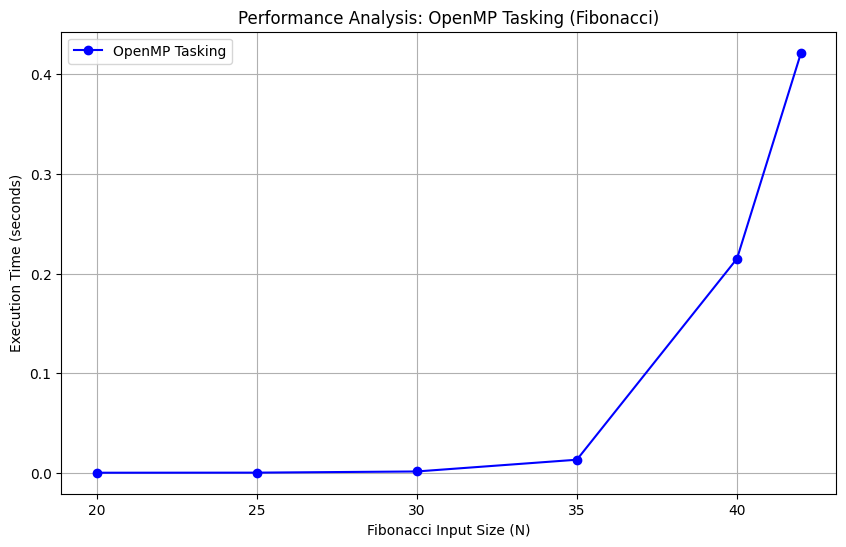

Section 5: Recursive Divide-and-Conquer Sum using
OpenMP Tasks

Aim

Apply OpenMP tasking to a divide-and-conquer

recursive array summation problem and compare it

with loop-based parallelism.

In [1]:
%%writefile openmp_task_sum.cpp
#include <iostream>
#include <vector>
#include <omp.h>
#include <cstdlib>

// --- CRITICAL SETTING FOR COLAB ---
// If the array chunk is smaller than this, we switch to a normal loop.
// This prevents creating millions of tasks and crashing the RAM.
#define CUTOFF 50000

// 1. Recursive Divide-and-Conquer (Tasking)
long long recursive_sum(const std::vector<int>& arr, int start, int end) {
    // Optimization: If chunk is small, do it serially
    if (end - start <= CUTOFF) {
        long long sum = 0;
        for (int i = start; i < end; ++i) {
            sum += arr[i];
        }
        return sum;
    }

    int mid = start + (end - start) / 2;
    long long x = 0, y = 0;

    // Create tasks for the split
    #pragma omp task shared(x)
    x = recursive_sum(arr, start, mid);

    #pragma omp task shared(y)
    y = recursive_sum(arr, mid, end);

    // Wait for children to finish
    #pragma omp taskwait
    return x + y;
}

// 2. Loop-Based Parallelism (For Comparison)
long long loop_sum(const std::vector<int>& arr) {
    long long total = 0;
    #pragma omp parallel for reduction(+:total)
    for (size_t i = 0; i < arr.size(); ++i) {
        total += arr[i];
    }
    return total;
}

int main(int argc, char* argv[]) {
    if (argc != 2) return 1;
    size_t N = std::atol(argv[1]);

    std::vector<int> arr(N, 1); // Fill array with 1s

    // Set threads (Colab usually gives you 2 vCPUs)
    omp_set_num_threads(4);

    // Benchmark Tasking
    double start = omp_get_wtime();
    long long task_res = 0;
    #pragma omp parallel
    {
        #pragma omp single
        task_res = recursive_sum(arr, 0, N);
    }
    double task_time = omp_get_wtime() - start;

    // Benchmark Loop
    start = omp_get_wtime();
    long long loop_res = loop_sum(arr);
    double loop_time = omp_get_wtime() - start;

    // Output: TaskTime,LoopTime
    std::cout << task_time << "," << loop_time << std::endl;
    return 0;
}

Writing openmp_task_sum.cpp


[+] Compiling openmp_task_sum.cpp...
[+] Compilation successful.
Array Size      | Task Time (s)   | Loop Time (s)  
-------------------------------------------------------
1000000         | 0.141531          | 0.000507
5000000         | 2.609310          | 0.001807
10000000        | 9.959310          | 0.006381
15000000        | 31.860500          | 0.005789
20000000        | 42.390700          | 0.007615


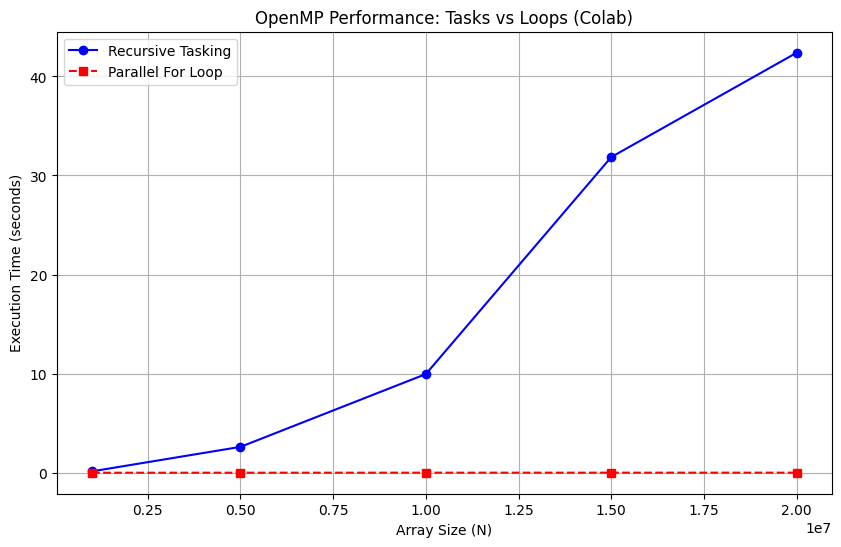

In [4]:
import subprocess
import matplotlib.pyplot as plt
import os

def run_benchmark_colab():
    # Define array sizes (Up to 20 Million to stay safe in Colab)
    input_sizes = [1_000_000, 5_000_000, 10_000_000, 15_000_000, 20_000_000]

    task_times = []
    loop_times = []

    cpp_source_file = "openmp_task_sum.cpp"
    executable_name = "./task_benchmark"

    # Compile the C++ code
    compile_cmd = ["g++", "-O3", "-fopenmp", cpp_source_file, "-o", executable_name]
    print(f"[+] Compiling {cpp_source_file}...")
    try:
        subprocess.check_call(compile_cmd)
        print("[+] Compilation successful.")
    except subprocess.CalledProcessError:
        print("[-] Compilation failed. Ensure g++ is installed and supports -fopenmp.")
        return
    except FileNotFoundError:
        print("[-] g++ compiler not found. Please install a C++ compiler.")
        return


    print(f"{'Array Size':<15} | {'Task Time (s)':<15} | {'Loop Time (s)':<15}")
    print("-" * 55)

    for n in input_sizes:
        try:
            # Call the compiled C++ executable
            result = subprocess.check_output([executable_name, str(n)])
            output_str = result.decode("utf-8").strip()

            # Parse the CSV output from C++
            t_task, t_loop = map(float, output_str.split(","))

            task_times.append(t_task)
            loop_times.append(t_loop)

            print(f"{n:<15} | {t_task:.6f}          | {t_loop:.6f}")
        except Exception as e:
            print(f"Error running size {n}: {e}")
            # If an error occurs, ensure no plotting happens with incomplete data
            if os.path.exists(executable_name): os.remove(executable_name) # Cleanup on error
            return # Exit function on first error

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(input_sizes, task_times, marker='o', label='Recursive Tasking', color='blue')
    plt.plot(input_sizes, loop_times, marker='s', label='Parallel For Loop', color='red', linestyle='--')

    plt.title("OpenMP Performance: Tasks vs Loops (Colab)")
    plt.xlabel("Array Size (N)")
    plt.ylabel("Execution Time (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cleanup the executable after plotting
    if os.path.exists(executable_name): os.remove(executable_name)

if __name__ == "__main__":
    run_benchmark_colab()